### 1. Import Libraries
In this step, we import all necessary Python libraries and modules:
- **`numpy` & `pandas`**: For data manipulation and processing.
- **`matplotlib` & `seaborn`**: For data visualization and plotting graphs.
- **`scikit-learn` (sklearn)**:
  - `make_regression`: To generate synthetic regression datasets if needed.
  - `train_test_split`: To split our dataset into training and testing sets.
  - `MinMaxScaler`: To normalize numerical features to a specific range (usually 0 to 1).
  - `OrdinalEncoder`, `OneHotEncoder`, `LabelEncoder`: To convert categorical text features into numerical values.
  - `LinearRegression` & `SGDRegressor`: Machine learning models used for linear regression (Ordinary Least Squares and Stochastic Gradient Descent).


In [125]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.linear_model import SGDRegressor

### 2. Dataset Generation and Visualization
In this step, we generate a synthetic dataset and split it into training and test sets:
- **`make_regression`**: Generates 400 data points with 1 feature (`n_features=1`) and adds random noise (`noise=3.79`) to simulate real-world data.
- **`train_test_split`**: Splits the dataset into 80% training data (`X_train`, `Y_train`) and 20% test data (`X_test`, `Y_test`).
- **Data Plotting**: Uses `matplotlib` scatter plots to visualize the distribution of:
  1. The complete dataset (`X`, `Y`)
  2. The training subset (`X_train`, `Y_train`)
  3. The testing subset (`X_test`, `Y_test`)


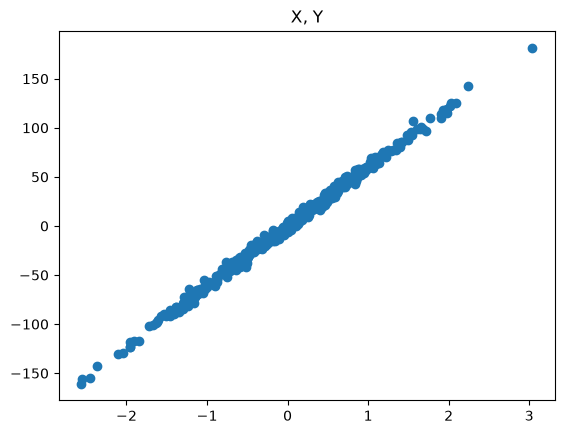

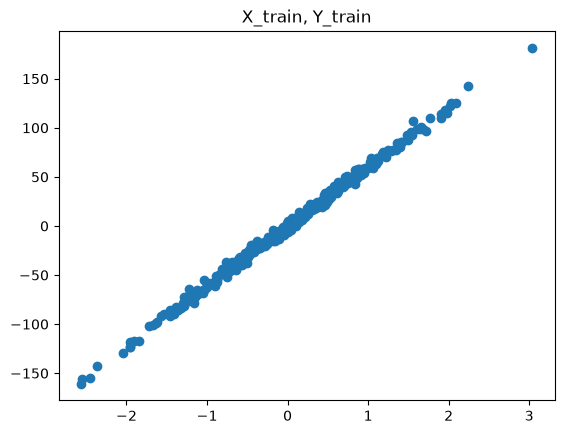

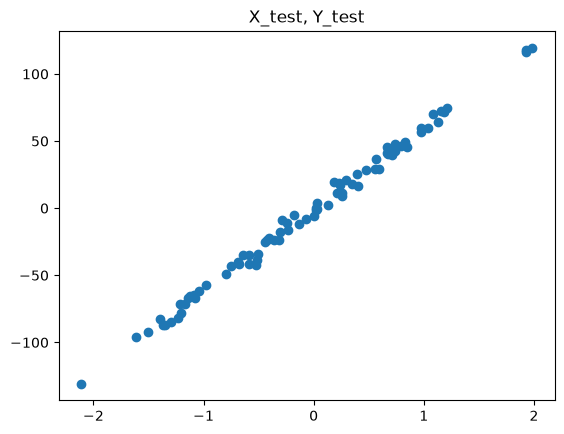

In [126]:
X, Y = make_regression(400, 1, n_informative = 1, noise = 3.79)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
plt.scatter(X, Y)
plt.title("X, Y")
plt.show()
plt.scatter(X_train, Y_train)
plt.title("X_train, Y_train")
plt.show()
plt.scatter(X_test, Y_test)
plt.title("X_test, Y_test")
plt.show()

### 3. Model Training and Evaluation (Ordinary Least Squares)
In this step, we train and evaluate a Linear Regression model:
- **`LinearRegression()`**: Initializes the model using Ordinary Least Squares (OLS).
- **`fit()`**: Trains the model using the training data (`X_train` and `Y_train`) to find the best-fitting line.
- **`score()`**: Evaluates the model performance on the unseen testing data (`X_test`, `Y_test`) by calculating the **$R^2$ score** (coefficient of determination).


In [127]:
lr = LinearRegression()
lr.fit(X_train, Y_train)
# y_pred = lr.predict(X_test) 
score = lr.score(X_test, Y_test)
print(score)

0.9949394062122684


### 4. Plotting the Fitted Regression Line
In this step, we visualize how well our trained linear regression model fits the dataset:
- **`np.arange(-3, +3, 0.1)`**: Creates a sequence of X values from -3 to 3 with a step size of 0.1.
- **`np.reshape(_x_range, (60, 1))`**: Reshapes the 1D array into a 2D column vector so `scikit-learn` can process it.
- **`lr.predict()`**: Calculates the predicted Y values along the generated X range.
- **Visualization**: Plots the original dataset points in red using a scatter plot, and overlays the model's fitted line.


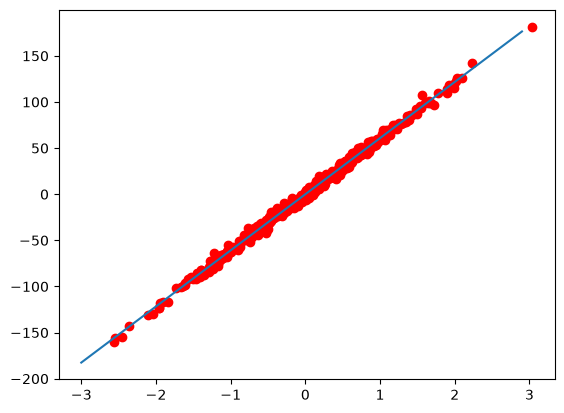

In [128]:
_x_range = np.arange(-3, +3, 0.1)
_x_range_2d = np.reshape(_x_range, (60, 1))
y_pred = lr.predict(_x_range_2d)

plt.scatter(X, Y, color="red")
plt.plot(_x_range, y_pred)

### 5. Real Dataset Preprocessing and Feature Scaling (Fish Dataset)
In this step, we load and prepare the real-world dataset for model training:
- **Data Loading**: Reads `Fish.csv` and renames columns with numerical indices (`0` to `6`).
- **One-Hot Encoding**: Converts the categorical feature (column `0`, species of fish) into binary indicator columns (0s and 1s) using `pd.get_dummies()`.
- **Feature Scaling**: Scales continuous numerical features (columns `1` to `6`) using `MinMaxScaler` so that all values range between 0 and 1.
- **Target Separation**: Extracts column `1` (Weight) as the target variable `Y` and assigns all remaining features to `X`.
- **Train-Test Split**: Converts `X` and `Y` into NumPy arrays and splits the dataset into 80% training and 20% testing sets.


In [129]:
data = pd.read_csv("./Fish.csv",).set_axis([0, 1, 2, 3, 4, 5, 6], axis=1)

one_hat = pd.get_dummies(data[[0]], dtype=int)
raw_data = data.drop(0, axis = 1)
data = raw_data.join(one_hat)

cont_attr = [1, 2, 3, 4, 5, 6]
min_max_scaler = MinMaxScaler()
x = data[cont_attr].values
x_scaled = min_max_scaler.fit_transform(x)

normalized = pd.DataFrame(x_scaled, columns=cont_attr, index=raw_data.index)
data[cont_attr] = normalized

Y = np.array(data.pop(1))
X = np.array(data)
print(X.shape, Y.shape)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
print(X_test.shape, Y_test.shape)

(159, 12) (159,)
(32, 12) (32,)


### 6. Training and Evaluating Model on Preprocessed Fish Dataset
In this step, we train a new Linear Regression model on the processed dataset and compare predictions:
- **`LinearRegression()`**: Initializes a second model instance (`lr_2`).
- **`fit()`**: Trains `lr_2` using the scaled multi-feature training set (`X_train`) and target weight (`Y_train`).
- **`score()`**: Computes the $R^2$ score on `X_test` to evaluate how well the multi-feature linear regression model performs on unseen data.
- **Prediction Comparison**: Extracts the first 5 samples from the test set (`sample_x_5` and `sample_y_5`) to directly print and compare actual target values (`Y_test`) against predicted values from `lr_2.predict()`.


In [130]:
lr_2 = LinearRegression()
lr_2.fit(X_train, Y_train)
# y_pred = lr_2.predict(X_test) 
score = lr_2.score(X_test, Y_test)
print(score)

sample_x_5 = X_test[:5,:]
sample_y_5 = Y_test[:5]

print(sample_y_5, lr_2.predict(sample_x_5), sep="\n")

0.9226281537122547
[0.14666667 0.57575758 0.10242424 0.00406061 0.15151515]
[ 0.16267751  0.56849036  0.16184895 -0.0475695   0.21243616]


### 7. Training Linear Regression using Stochastic Gradient Descent (SGD)
In this step, we train a linear regression model using an iterative optimization algorithm (SGD):
- **`SGDRegressor()`**: Initializes the model with custom convergence parameters:
  - `max_iter=500000`: Sets the maximum number of training passes (epochs) over the data.
  - `tol=1e-8` ($10^{-8}$): Defines the stopping tolerance threshold for early convergence.
- **`fit()`**: Trains the model using stochastic gradient descent on `X_train` and `Y_train`.
- **`score()`**: Calculates the $R^2$ performance score on the test set (`X_test`, `Y_test`).
- **`n_iter_`**: Displays the actual number of iterations completed before meeting the stopping criterion or reaching `max_iter`.


In [131]:
lr_gd = SGDRegressor(max_iter=500000, tol=0.00000001)
lr_gd.fit(X_train, Y_train)
score = lr_gd.score(X_test, Y_test)
print(score, lr_gd.n_iter_)

0.9057694660592044 1208
